# Adversarial Image Generation: GAN and Conditional GAN

This notebook implements Vanilla GAN and Conditional GAN (cGAN) on the MNIST dataset using PyTorch. It preserves the original training setup, visualizations, saved checkpoints, and comparative results.


1. Import Required Libraries

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import clear_output

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


2. Define Hyperparameters

In [ ]:
LEARNING_RATE = 0.0002
BATCH_SIZE = 128
EPOCHS = 50
LATENT_DIM = 100  # Size of random noise vector
IMAGE_SIZE = 28 * 28  # MNIST images are 28x28
NUM_CLASSES = 10  # MNIST has 10 digit classes (0-9)

# Adam optimizer parameters
BETA1 = 0.5
BETA2 = 0.999

# Visualization frequency
VISUALIZE_EVERY = 10

print(f"Hyperparameters:")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Latent Dimension: {LATENT_DIM}")
print(f"  Image Size: {IMAGE_SIZE} ({int(np.sqrt(IMAGE_SIZE))}x{int(np.sqrt(IMAGE_SIZE))})")

Hyperparameters:
  Learning Rate: 0.0002
  Batch Size: 128
  Epochs: 50
  Latent Dimension: 100
  Image Size: 784 (28x28)


## 3. Load and Prepare MNIST Dataset

Dataset loaded: 60000 training images
Number of batches: 469


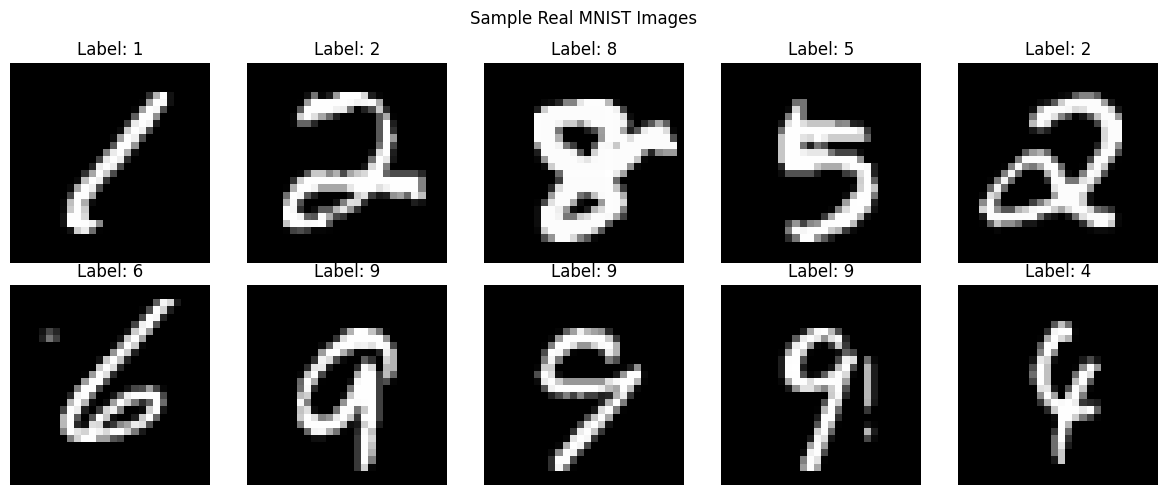

In [8]:
# Transform to normalize images to [-1, 1] range (required for Tanh activation)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
])

# Load MNIST dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Create DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # Set to 0 for Windows compatibility
)

print(f"Dataset loaded: {len(train_dataset)} training images")
print(f"Number of batches: {len(train_loader)}")

# Visualize some real images
sample_batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    img = sample_batch[0][i].cpu().numpy().squeeze()
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f'Label: {sample_batch[1][i]}')
plt.suptitle('Sample Real MNIST Images')
plt.tight_layout()
plt.show()

## 4. Define Generator Network

flexible for both vanilla GAN and cGAN:
- Takes random noise vector as input
- Optionally accepts class labels for conditional generation
- Uses LeakyReLU activations in hidden layers
- Uses Tanh activation in output layer (to generate images in [-1, 1] range)

In [9]:
class Generator(nn.Module):
    """
    Generator network for GAN.
    Flexible design to support both vanilla GAN and conditional GAN (cGAN).
    
    Args:
        latent_dim: Dimension of input noise vector
        num_classes: Number of classes (for cGAN)
        conditional: Whether to use conditional generation
    """
    def __init__(self, latent_dim=100, num_classes=10, conditional=False):
        super(Generator, self).__init__()
        
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.conditional = conditional
        
        # If conditional, input dimension includes one-hot encoded label
        input_dim = latent_dim + num_classes if conditional else latent_dim
        
        # Define the network architecture
        self.model = nn.Sequential(
            # First layer: input_dim -> 256
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Second layer: 256 -> 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Third layer: 512 -> 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Output layer: 1024 -> 784 (28x28)
            nn.Linear(1024, IMAGE_SIZE),
            nn.Tanh()  # Output in range [-1, 1]
        )
        
    def forward(self, z, labels=None):
        """
        Forward pass through the generator.
        
        Args:
            z: Random noise vector of shape (batch_size, latent_dim)
            labels: Optional class labels for conditional generation (batch_size,)
        
        Returns:
            Generated images of shape (batch_size, 1, 28, 28)
        """
        if self.conditional and labels is not None:
            # Convert labels to one-hot encoding
            labels_onehot = torch.zeros(z.size(0), self.num_classes, device=z.device)
            labels_onehot.scatter_(1, labels.unsqueeze(1), 1)
            
            # Concatenate noise with one-hot labels
            gen_input = torch.cat([z, labels_onehot], dim=1)
        else:
            gen_input = z
        
        # Generate image
        img = self.model(gen_input)
        
        # Reshape to image format (batch_size, 1, 28, 28)
        img = img.view(img.size(0), 1, 28, 28)
        
        return img

# Test the generator
test_gen = Generator(latent_dim=LATENT_DIM, conditional=False).to(device)
test_noise = torch.randn(1, LATENT_DIM).to(device)
test_output = test_gen(test_noise)
print(f"Generator output shape: {test_output.shape}")
print(f"Number of parameters: {sum(p.numel() for p in test_gen.parameters()):,}")
del test_gen, test_noise, test_output

Generator output shape: torch.Size([1, 1, 28, 28])
Number of parameters: 1,486,352


## 5. Define Discriminator Network

The Discriminator is designed to be flexible for both vanilla GAN and cGAN:
- Takes 28×28 image as input
- Optionally accepts class labels for conditional discrimination
- Uses LeakyReLU activations in hidden layers
- Uses Sigmoid activation in output layer (probability that image is real)

In [10]:
class Discriminator(nn.Module):
    """
    Discriminator network for GAN.
    Flexible design to support both vanilla GAN and conditional GAN (cGAN).
    
    Args:
        num_classes: Number of classes (for cGAN)
        conditional: Whether to use conditional discrimination
    """
    def __init__(self, num_classes=10, conditional=False):
        super(Discriminator, self).__init__()
        
        self.num_classes = num_classes
        self.conditional = conditional
        
        # If conditional, input dimension includes one-hot encoded label
        input_dim = IMAGE_SIZE + num_classes if conditional else IMAGE_SIZE
        
        # Define the network architecture
        self.model = nn.Sequential(
            # First layer: input_dim -> 512
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            
            # Second layer: 512 -> 256
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            
            # Output layer: 256 -> 1
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output probability [0, 1]
        )
        
    def forward(self, img, labels=None):
        """
        Forward pass through the discriminator.
        
        Args:
            img: Input images of shape (batch_size, 1, 28, 28)
            labels: Optional class labels for conditional discrimination (batch_size,)
        
        Returns:
            Probability that image is real (batch_size, 1)
        """
        # Flatten image
        img_flat = img.view(img.size(0), -1)
        
        if self.conditional and labels is not None:
            # Convert labels to one-hot encoding
            labels_onehot = torch.zeros(img.size(0), self.num_classes, device=img.device)
            labels_onehot.scatter_(1, labels.unsqueeze(1), 1)
            
            # Concatenate flattened image with one-hot labels
            disc_input = torch.cat([img_flat, labels_onehot], dim=1)
        else:
            disc_input = img_flat
        
        # Output probability
        validity = self.model(disc_input)
        
        return validity

# Test the discriminator
test_disc = Discriminator(conditional=False).to(device)
test_img = torch.randn(1, 1, 28, 28).to(device)
test_output = test_disc(test_img)
print(f"Discriminator output shape: {test_output.shape}")
print(f"Number of parameters: {sum(p.numel() for p in test_disc.parameters()):,}")
del test_disc, test_img, test_output

Discriminator output shape: torch.Size([1, 1])
Number of parameters: 533,505


## 6. Utility Functions for Visualization

In [11]:
def generate_and_visualize(generator, epoch, num_images=16, labels=None, title_prefix=""):
    """
    Generate and visualize images using the generator.
    
    Args:
        generator: Generator model
        epoch: Current epoch number
        num_images: Number of images to generate
        labels: Optional labels for conditional generation
        title_prefix: Prefix for the plot title
    """
    generator.eval()
    with torch.no_grad():
        # Generate random noise
        z = torch.randn(num_images, LATENT_DIM).to(device)
        
        # Generate images
        if labels is not None:
            labels = labels.to(device)
            generated_imgs = generator(z, labels)
        else:
            generated_imgs = generator(z)
        
        # Plot images
        fig, axes = plt.subplots(4, 4, figsize=(10, 10))
        for i, ax in enumerate(axes.flatten()):
            img = generated_imgs[i].cpu().numpy().squeeze()
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            if labels is not None:
                ax.set_title(f'Class: {labels[i].item()}')
        
        plt.suptitle(f'{title_prefix}Generated Images - Epoch {epoch}')
        plt.tight_layout()
        plt.show()
    
    generator.train()

def plot_losses(g_losses, d_losses, title="Training Losses"):
    """
    Plot generator and discriminator losses.
    
    Args:
        g_losses: List of generator losses
        d_losses: List of discriminator losses
        title: Plot title
    """
    plt.figure(figsize=(10, 5))
    plt.plot(g_losses, label='Generator Loss', alpha=0.7)
    plt.plot(d_losses, label='Discriminator Loss', alpha=0.7)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Train Vanilla GAN

Training procedure:
1. Train Discriminator:
   - Forward pass real images (labeled as real)
   - Forward pass fake images (labeled as fake)
   - Compute loss and backpropagate

2. Train Generator:
   - Generate fake images
   - Try to fool discriminator (label fakes as real)
   - Compute loss and backpropagate

In [12]:

# Initialize models
generator = Generator(latent_dim=LATENT_DIM, conditional=False).to(device)
discriminator = Discriminator(conditional=False).to(device)

# Loss function
criterion = nn.BCELoss()

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

VANILLA_GAN_PATH = 'models/vanilla_gan_generator.pth'
vanilla_gan_trained = False

if os.path.exists(VANILLA_GAN_PATH):
    checkpoint = torch.load(VANILLA_GAN_PATH, map_location=device)
    generator.load_state_dict(checkpoint['model_state_dict'])
    optimizer_G.load_state_dict(checkpoint['optimizer_state_dict'])
    g_losses = [checkpoint.get('loss', 0.0)]
    d_losses = [0.0]
    vanilla_gan_trained = True
    print(f"Loaded Vanilla GAN Generator from '{VANILLA_GAN_PATH}' (epoch {checkpoint.get('epoch', '?')})")
else:
    print("Vanilla GAN initialized (no saved model found, will train from scratch)")

print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")


Vanilla GAN initialized (no saved model found, will train from scratch)
Generator parameters: 1,486,352
Discriminator parameters: 533,505


Starting Vanilla GAN training...

Epoch [1/50] | D Loss: 0.5816 | G Loss: 0.9670


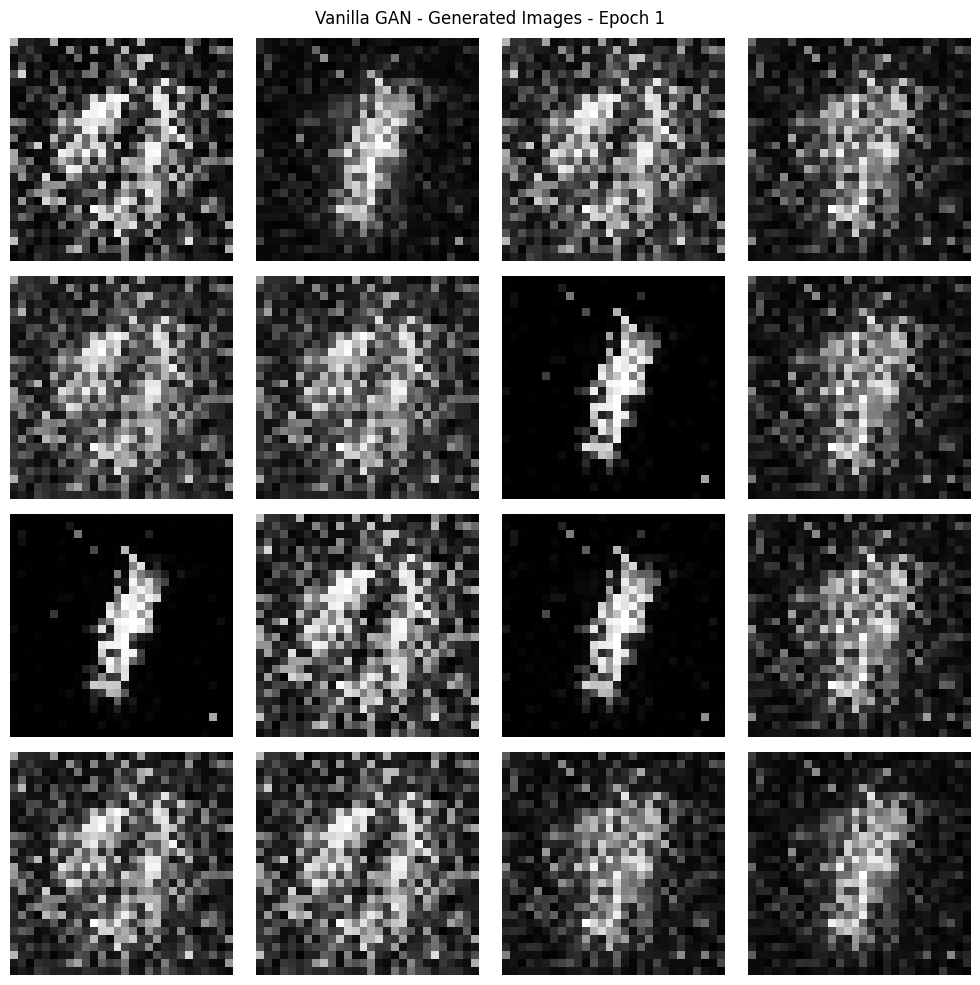

Epoch [2/50] | D Loss: 0.4564 | G Loss: 1.7363
Epoch [3/50] | D Loss: 0.4541 | G Loss: 1.8487
Epoch [4/50] | D Loss: 0.4236 | G Loss: 1.9046
Epoch [5/50] | D Loss: 0.4421 | G Loss: 1.8604
Epoch [6/50] | D Loss: 0.4092 | G Loss: 1.9761
Epoch [7/50] | D Loss: 0.4039 | G Loss: 2.0027
Epoch [8/50] | D Loss: 0.3994 | G Loss: 1.9346
Epoch [9/50] | D Loss: 0.4229 | G Loss: 1.8254
Epoch [10/50] | D Loss: 0.4401 | G Loss: 1.6556


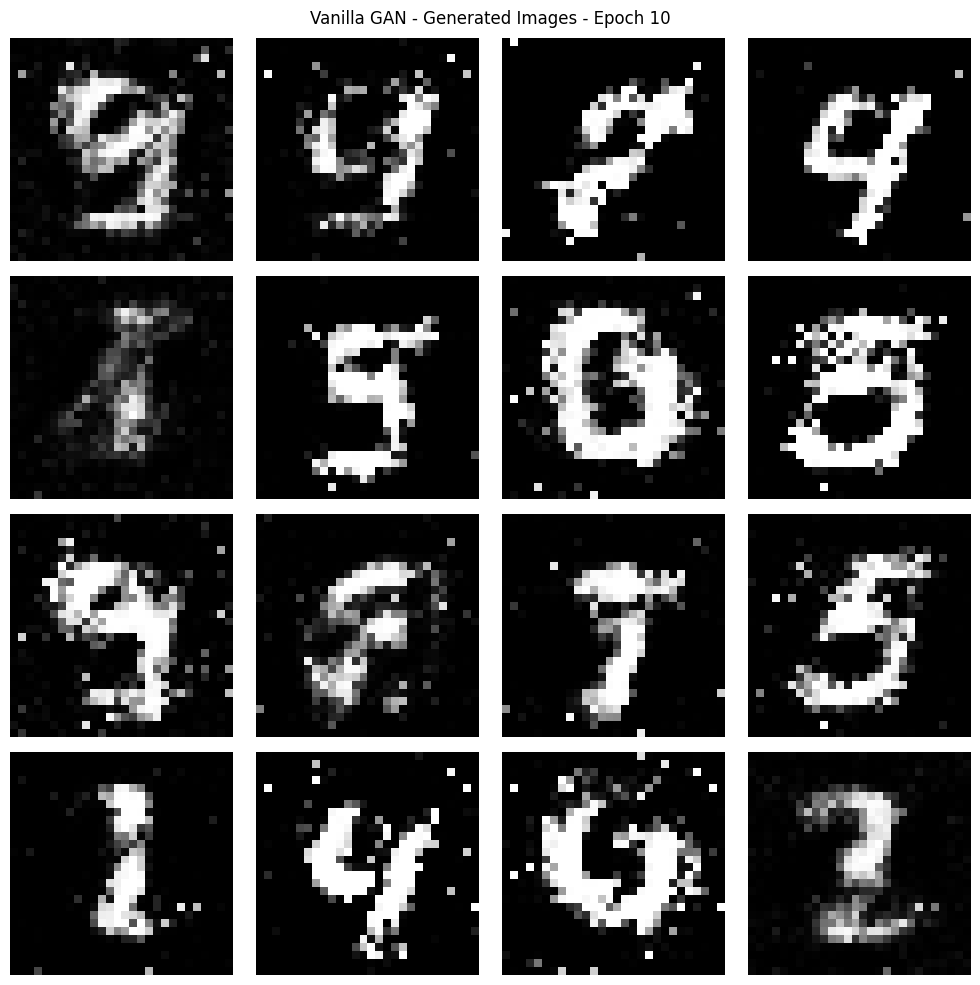

Epoch [11/50] | D Loss: 0.5041 | G Loss: 1.3791
Epoch [12/50] | D Loss: 0.5400 | G Loss: 1.2128
Epoch [13/50] | D Loss: 0.5549 | G Loss: 1.1654
Epoch [14/50] | D Loss: 0.5678 | G Loss: 1.1137
Epoch [15/50] | D Loss: 0.5811 | G Loss: 1.0596
Epoch [16/50] | D Loss: 0.5807 | G Loss: 1.0719
Epoch [17/50] | D Loss: 0.5801 | G Loss: 1.0722
Epoch [18/50] | D Loss: 0.5854 | G Loss: 1.0510
Epoch [19/50] | D Loss: 0.5866 | G Loss: 1.0490
Epoch [20/50] | D Loss: 0.5958 | G Loss: 1.0313


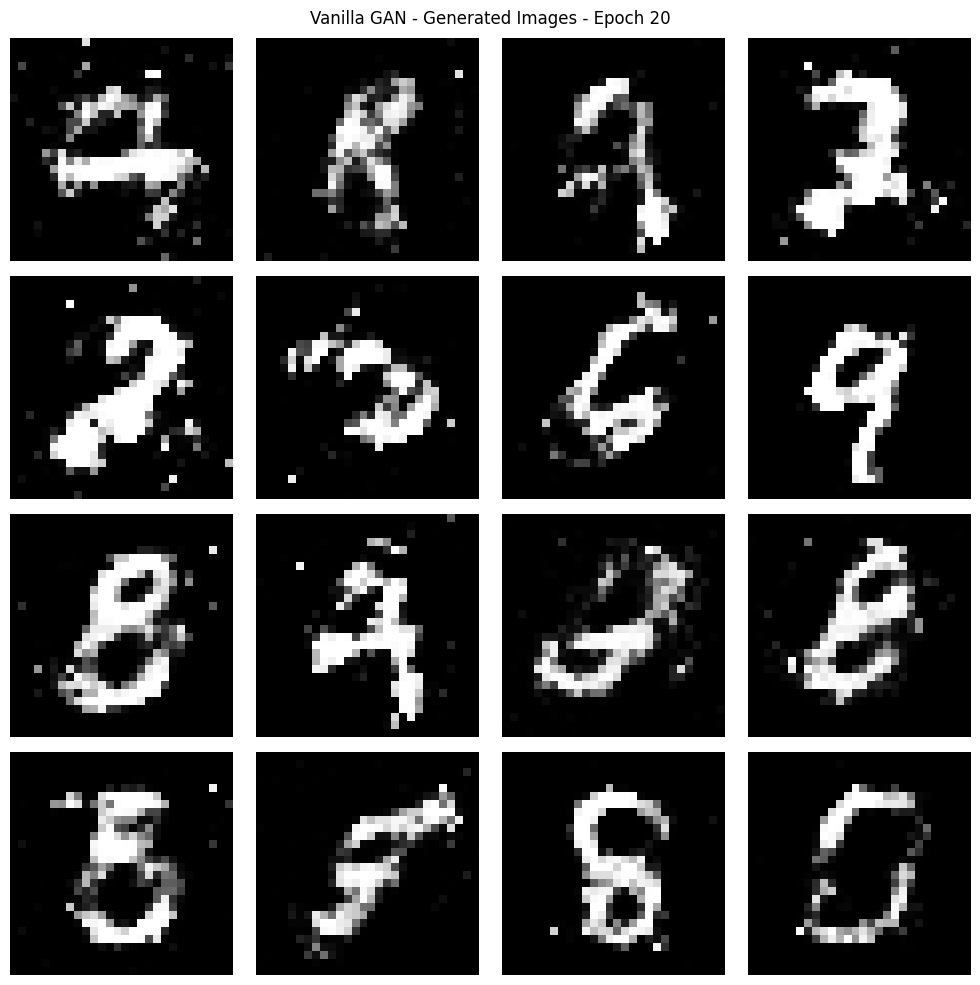

Epoch [21/50] | D Loss: 0.5906 | G Loss: 1.0376
Epoch [22/50] | D Loss: 0.5948 | G Loss: 1.0281
Epoch [23/50] | D Loss: 0.5945 | G Loss: 1.0252
Epoch [24/50] | D Loss: 0.6001 | G Loss: 1.0075
Epoch [25/50] | D Loss: 0.6035 | G Loss: 1.0038
Epoch [26/50] | D Loss: 0.6068 | G Loss: 0.9907
Epoch [27/50] | D Loss: 0.6059 | G Loss: 0.9945
Epoch [28/50] | D Loss: 0.6068 | G Loss: 0.9948
Epoch [29/50] | D Loss: 0.6100 | G Loss: 0.9868
Epoch [30/50] | D Loss: 0.6117 | G Loss: 0.9792


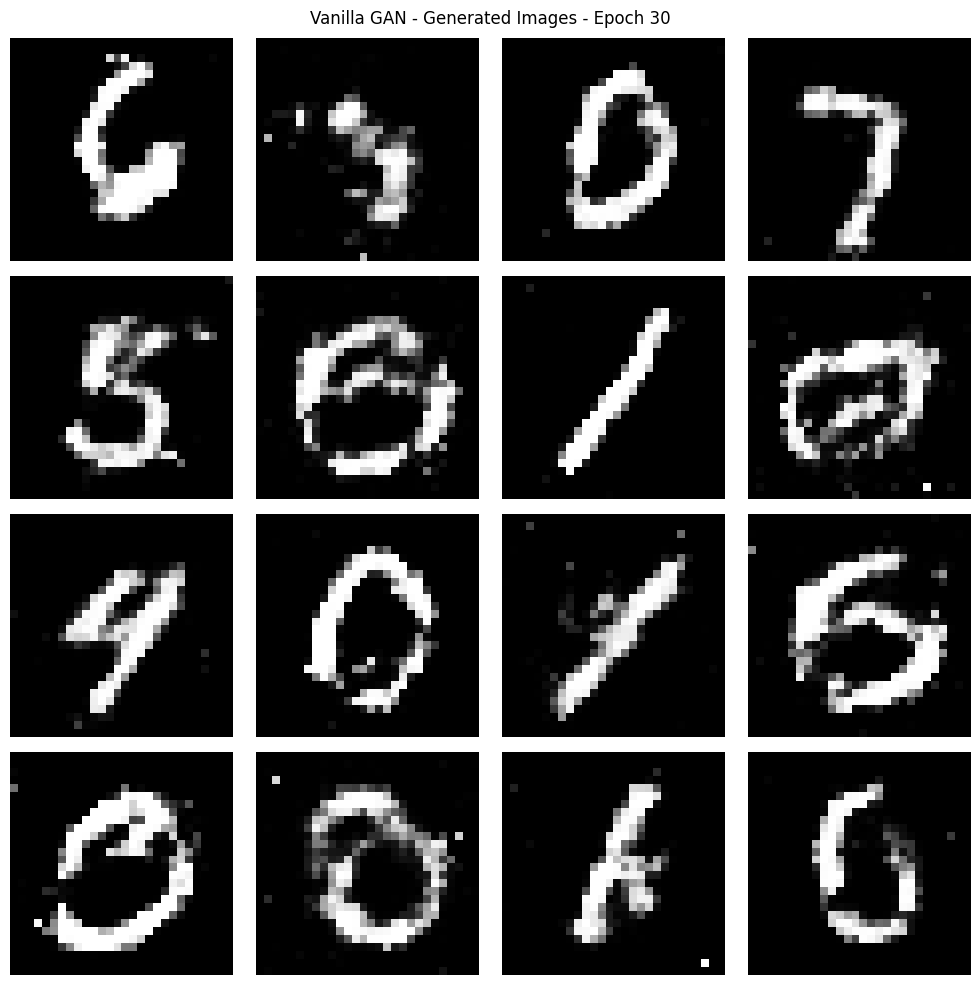

Epoch [31/50] | D Loss: 0.6125 | G Loss: 0.9799
Epoch [32/50] | D Loss: 0.6151 | G Loss: 0.9747
Epoch [33/50] | D Loss: 0.6155 | G Loss: 0.9719
Epoch [34/50] | D Loss: 0.6187 | G Loss: 0.9637
Epoch [35/50] | D Loss: 0.6213 | G Loss: 0.9529
Epoch [36/50] | D Loss: 0.6180 | G Loss: 0.9656
Epoch [37/50] | D Loss: 0.6211 | G Loss: 0.9544
Epoch [38/50] | D Loss: 0.6239 | G Loss: 0.9409
Epoch [39/50] | D Loss: 0.6235 | G Loss: 0.9438
Epoch [40/50] | D Loss: 0.6259 | G Loss: 0.9355


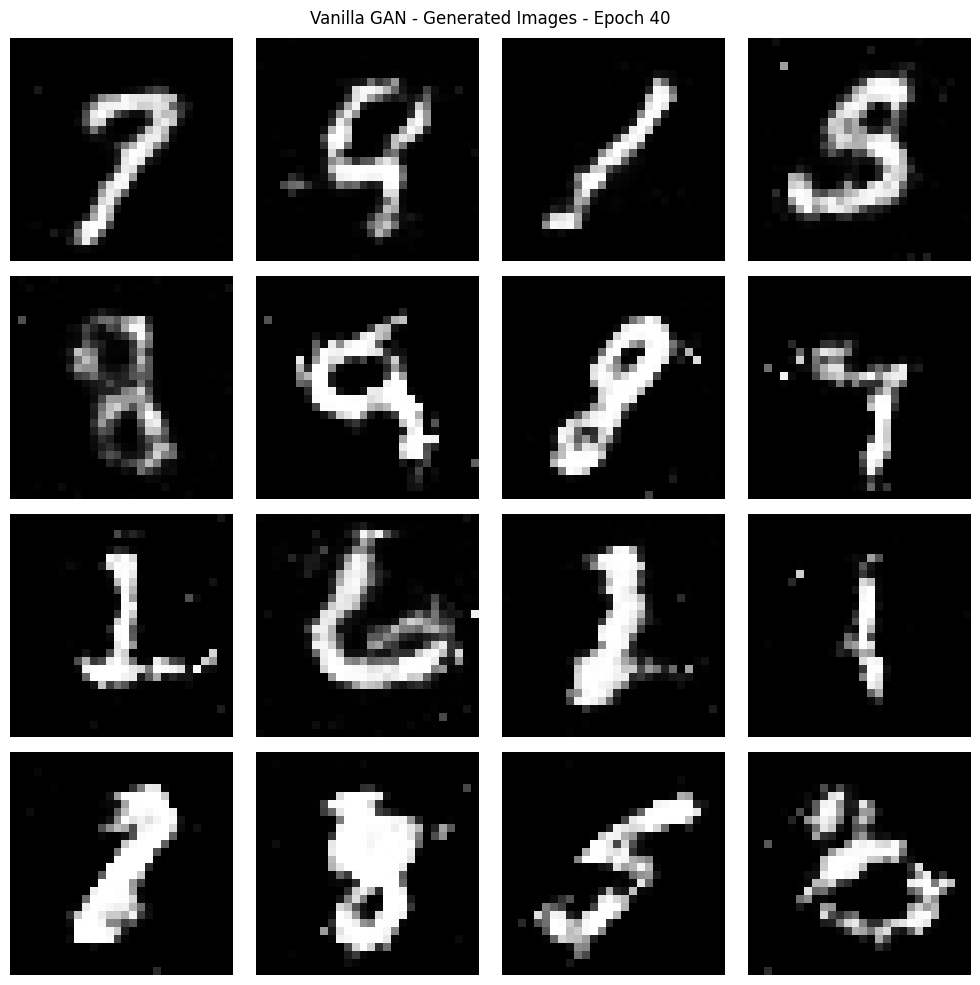

Epoch [41/50] | D Loss: 0.6282 | G Loss: 0.9324
Epoch [42/50] | D Loss: 0.6287 | G Loss: 0.9346
Epoch [43/50] | D Loss: 0.6305 | G Loss: 0.9264
Epoch [44/50] | D Loss: 0.6284 | G Loss: 0.9251
Epoch [45/50] | D Loss: 0.6319 | G Loss: 0.9179
Epoch [46/50] | D Loss: 0.6325 | G Loss: 0.9219
Epoch [47/50] | D Loss: 0.6291 | G Loss: 0.9244
Epoch [48/50] | D Loss: 0.6342 | G Loss: 0.9156
Epoch [49/50] | D Loss: 0.6344 | G Loss: 0.9087
Epoch [50/50] | D Loss: 0.6336 | G Loss: 0.9148


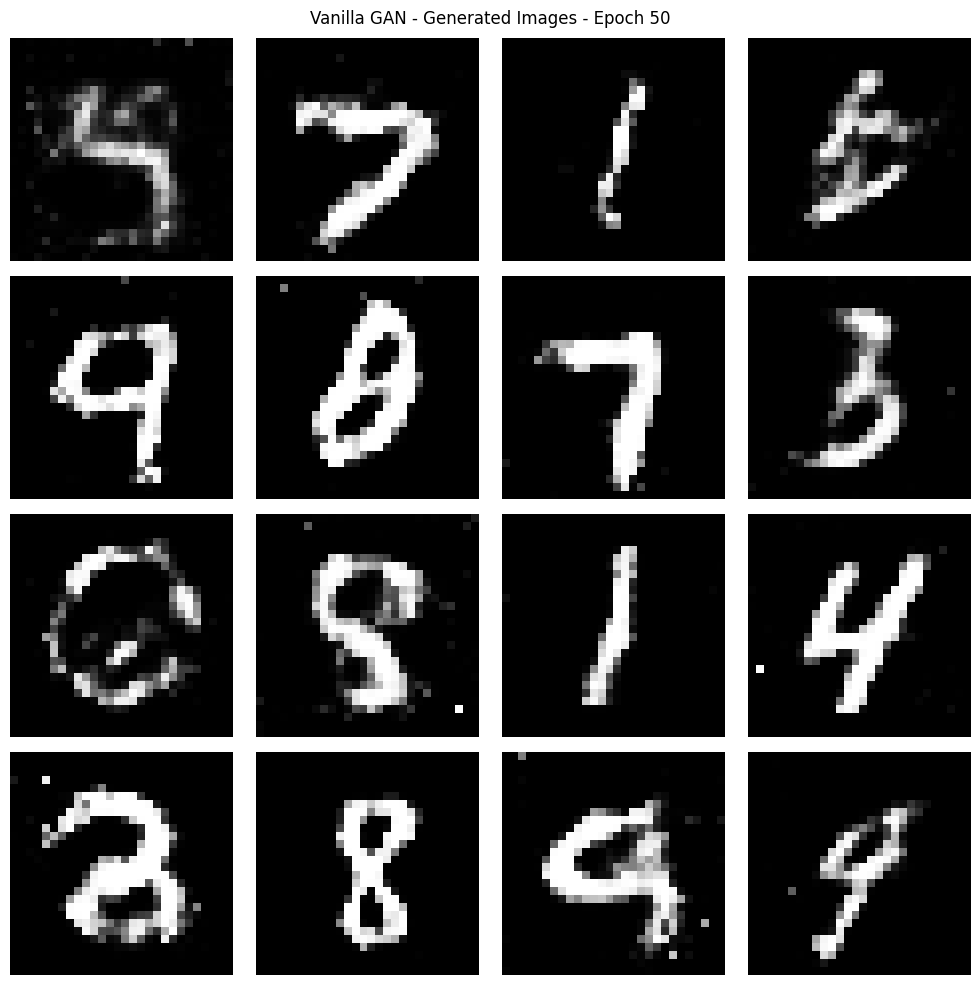


Vanilla GAN training completed!
Vanilla GAN Generator saved to 'models/vanilla_gan_generator.pth'


In [ ]:

if vanilla_gan_trained:
    print("Skipping Vanilla GAN training — loaded from saved model.")
    generate_and_visualize(generator, "Loaded", title_prefix="Vanilla GAN (Loaded) - ")
else:
    # Training loop for Vanilla GAN
    print("Starting Vanilla GAN training...\n")

    g_losses = []
    d_losses = []

    for epoch in range(EPOCHS):
        epoch_g_loss = 0
        epoch_d_loss = 0
        
        for batch_idx, (real_imgs, _) in enumerate(train_loader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            
            # Labels for real and fake images
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            
            # =================== Train Discriminator ===================
            optimizer_D.zero_grad()
            
            # Loss on real images
            real_validity = discriminator(real_imgs)
            d_loss_real = criterion(real_validity, real_labels)
            
            # Generate fake images
            z = torch.randn(batch_size, LATENT_DIM).to(device)
            fake_imgs = generator(z)
            
            # Loss on fake images
            fake_validity = discriminator(fake_imgs.detach())#only update discriminator, so detach fake images from generator graph
            d_loss_fake = criterion(fake_validity, fake_labels)
            
            # Total discriminator loss
            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()
            optimizer_D.step()
            
            # =================== Train Generator ===================
            optimizer_G.zero_grad()
            
            # Generate fake images
            z = torch.randn(batch_size, LATENT_DIM).to(device)
            gen_imgs = generator(z)
            
            # Generator tries to fool discriminator
            validity = discriminator(gen_imgs)
            g_loss = criterion(validity, real_labels)  # We want discriminator to think these are real
            
            g_loss.backward()
            optimizer_G.step()
            
            # Accumulate losses
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
        
        # Average losses for the epoch
        avg_g_loss = epoch_g_loss / len(train_loader)
        avg_d_loss = epoch_d_loss / len(train_loader)
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        
        # Print progress
        print(f"Epoch [{epoch+1}/{EPOCHS}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")
        
        # Visualize generated images every 10 epochs
        if (epoch + 1) % VISUALIZE_EVERY == 0 or epoch == 0:
            generate_and_visualize(generator, epoch+1, title_prefix="Vanilla GAN - ")

    print("\nVanilla GAN training completed!")

    # Save the model after training
    os.makedirs('models', exist_ok=True)
    torch.save({
        'epoch': EPOCHS,
        'model_state_dict': generator.state_dict(),
        'optimizer_state_dict': optimizer_G.state_dict(),
        'loss': g_losses[-1],
    }, VANILLA_GAN_PATH)
    print(f"Vanilla GAN Generator saved to '{VANILLA_GAN_PATH}'")


## 8. Plot Training Losses for Vanilla GAN

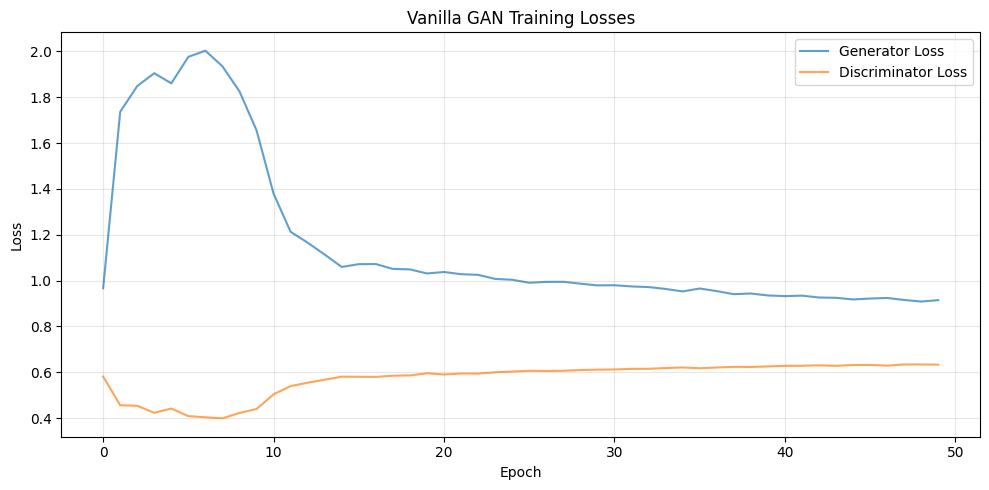

In [14]:
plot_losses(g_losses, d_losses, title="Vanilla GAN Training Losses")

## 9. Save Vanilla GAN Generator Model

In [15]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained generator
torch.save({
    'epoch': EPOCHS,
    'model_state_dict': generator.state_dict(),
    'optimizer_state_dict': optimizer_G.state_dict(),
    'loss': g_losses[-1],
}, 'models/vanilla_gan_generator.pth')

print("Vanilla GAN Generator saved to 'models/vanilla_gan_generator.pth'")

Vanilla GAN Generator saved to 'models/vanilla_gan_generator.pth'


## 10. Generate New Digits Using Trained Vanilla GAN

Generating new digits using trained Vanilla GAN...


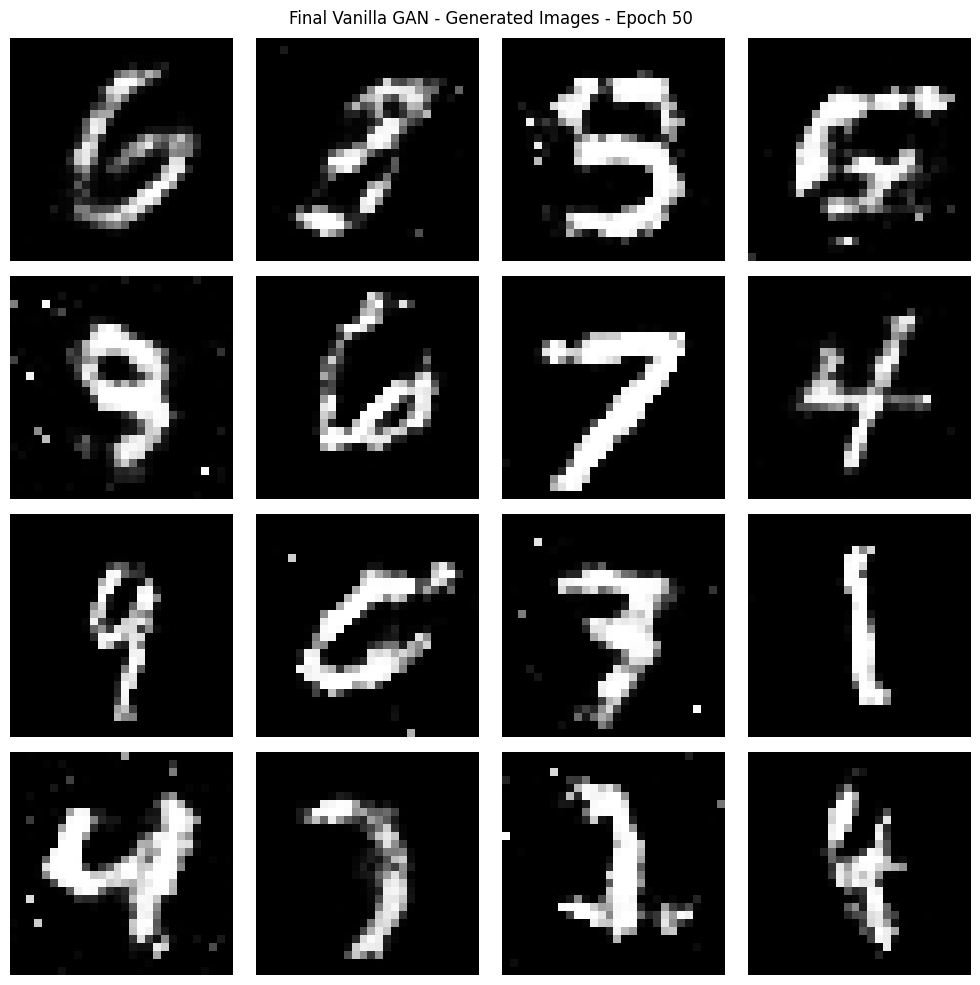

In [16]:
# Generate a batch of images using the trained generator
print("Generating new digits using trained Vanilla GAN...")
generate_and_visualize(generator, EPOCHS, num_images=16, title_prefix="Final Vanilla GAN - ")

## 11. Implement Conditional GAN (cGAN)

Now we modify the GAN to be conditional on class labels.

**Key Modifications:**
1. Generator accepts both noise and label (one-hot encoded)
2. Discriminator accepts both image and label (one-hot encoded)
3. Training includes label conditioning

In [ ]:

# Initialize Conditional GAN models
cgan_generator = Generator(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, conditional=True).to(device)
cgan_discriminator = Discriminator(num_classes=NUM_CLASSES, conditional=True).to(device)
#momentum(how much past grad influence),varience (howstable step size)
# Loss function
criterion = nn.BCELoss()

# Optimizers
optimizer_cG = optim.Adam(cgan_generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
optimizer_cD = optim.Adam(cgan_discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

CGAN_PATH = 'models/cgan_generator.pth'
cgan_trained = False

if os.path.exists(CGAN_PATH):
    checkpoint = torch.load(CGAN_PATH, map_location=device)
    cgan_generator.load_state_dict(checkpoint['model_state_dict'])
    optimizer_cG.load_state_dict(checkpoint['optimizer_state_dict'])
    cgan_g_losses = [checkpoint.get('loss', 0.0)]
    cgan_d_losses = [0.0]
    cgan_trained = True
    print(f"Loaded Conditional GAN Generator from '{CGAN_PATH}' (epoch {checkpoint.get('epoch', '?')})")
else:
    print("Conditional GAN initialized (no saved model found, will train from scratch)")

print(f"Generator parameters: {sum(p.numel() for p in cgan_generator.parameters()):,}")
print(f"Discriminator parameters: {sum(p.numel() for p in cgan_discriminator.parameters()):,}")


Conditional GAN initialized (no saved model found, will train from scratch)
Generator parameters: 1,488,912
Discriminator parameters: 538,625


## 12. Train Conditional GAN (cGAN)

Starting Conditional GAN training...

Epoch [1/50] | D Loss: 0.5405 | G Loss: 1.1511


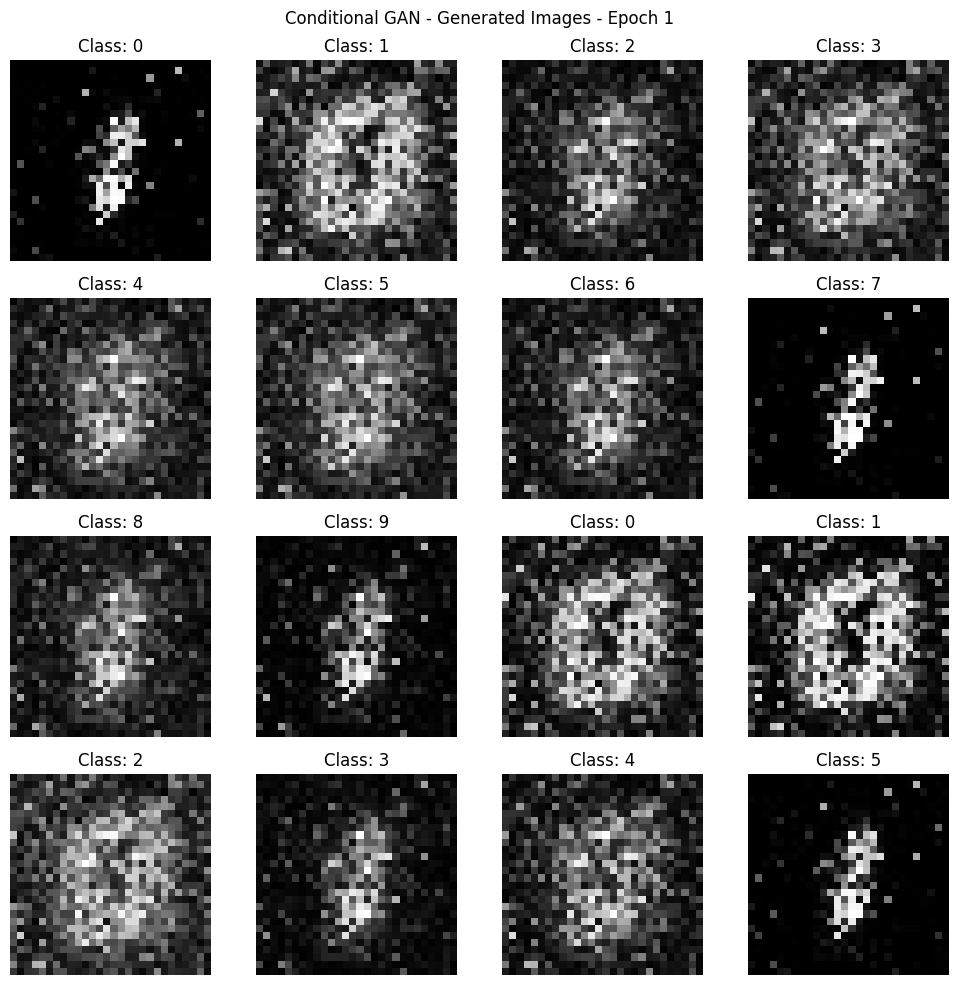

Epoch [2/50] | D Loss: 0.4208 | G Loss: 2.0901
Epoch [3/50] | D Loss: 0.3885 | G Loss: 2.3034
Epoch [4/50] | D Loss: 0.3685 | G Loss: 2.3450
Epoch [5/50] | D Loss: 0.3219 | G Loss: 2.5995
Epoch [6/50] | D Loss: 0.3504 | G Loss: 2.4110
Epoch [7/50] | D Loss: 0.4061 | G Loss: 1.9876
Epoch [8/50] | D Loss: 0.4271 | G Loss: 1.8068
Epoch [9/50] | D Loss: 0.4433 | G Loss: 1.6951
Epoch [10/50] | D Loss: 0.4970 | G Loss: 1.4180


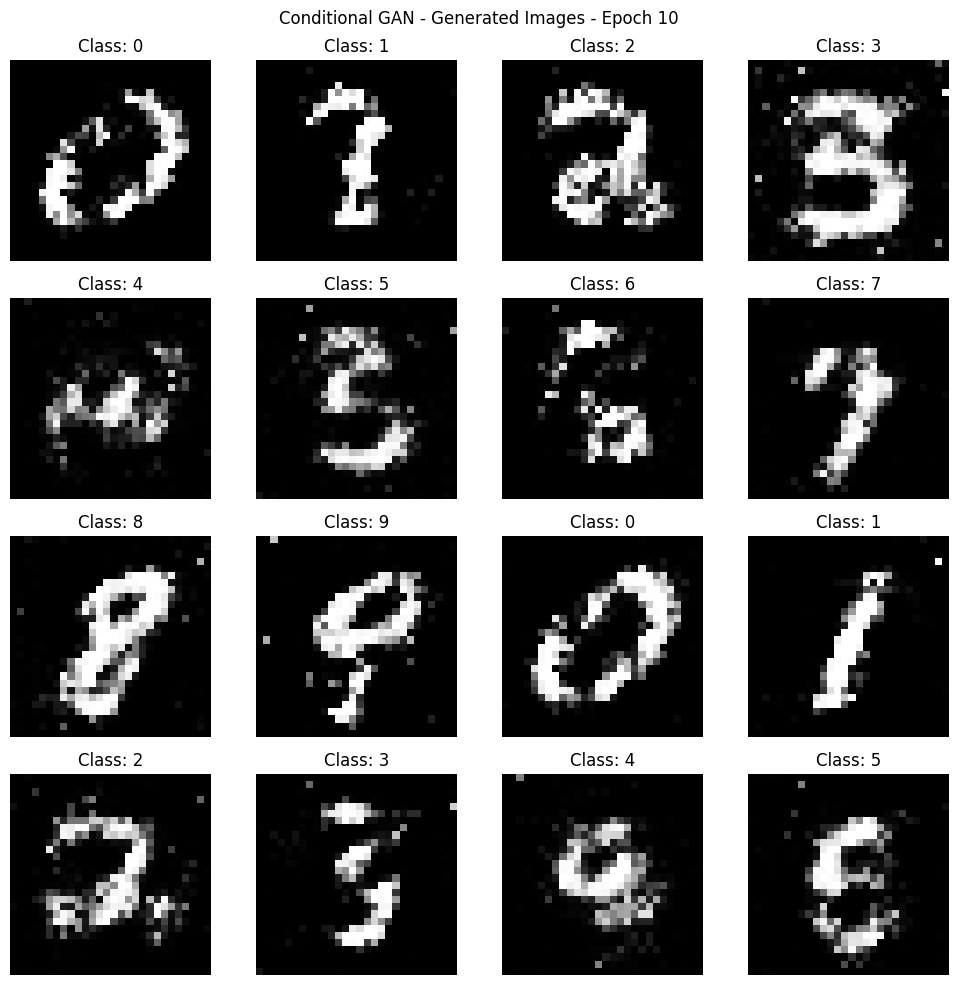

Epoch [11/50] | D Loss: 0.5211 | G Loss: 1.2980
Epoch [12/50] | D Loss: 0.5364 | G Loss: 1.2298
Epoch [13/50] | D Loss: 0.5414 | G Loss: 1.2286
Epoch [14/50] | D Loss: 0.5668 | G Loss: 1.1284
Epoch [15/50] | D Loss: 0.5848 | G Loss: 1.0583
Epoch [16/50] | D Loss: 0.5952 | G Loss: 1.0276
Epoch [17/50] | D Loss: 0.6010 | G Loss: 1.0056
Epoch [18/50] | D Loss: 0.6204 | G Loss: 0.9594
Epoch [19/50] | D Loss: 0.6271 | G Loss: 0.9340
Epoch [20/50] | D Loss: 0.6298 | G Loss: 0.9191


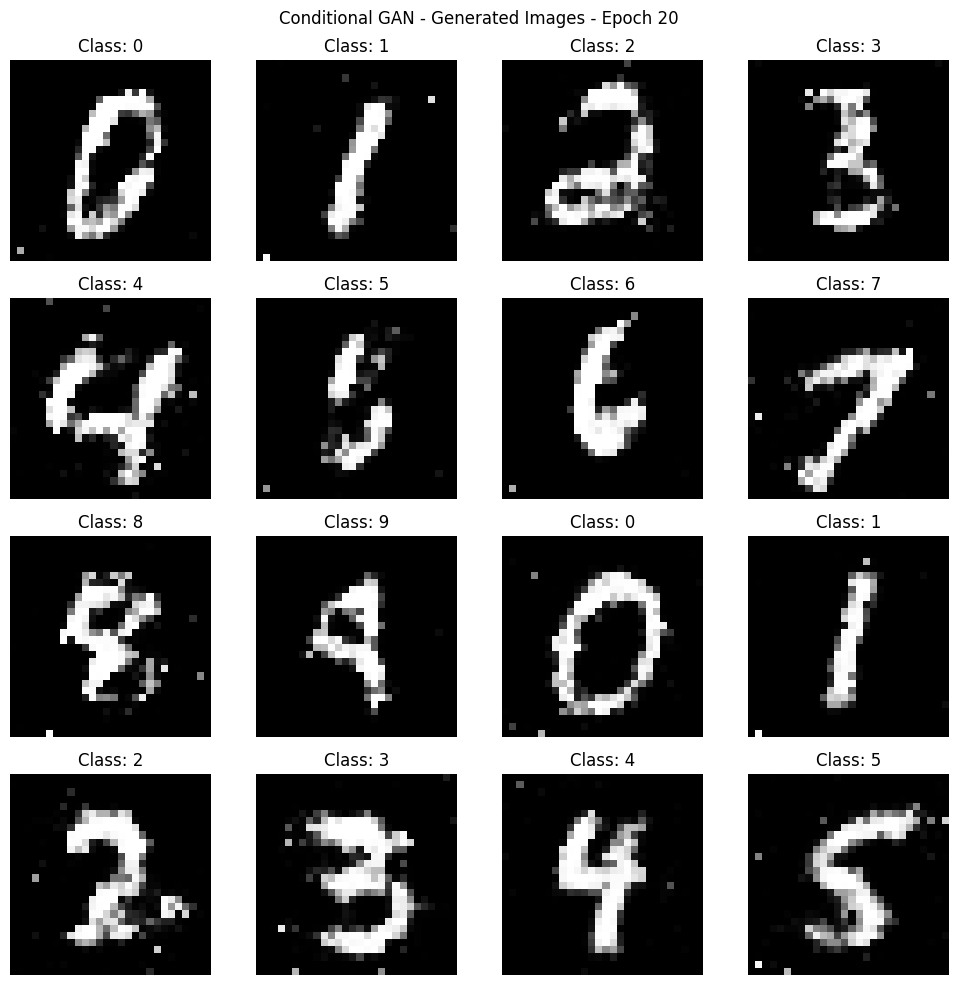

Epoch [21/50] | D Loss: 0.6355 | G Loss: 0.9051
Epoch [22/50] | D Loss: 0.6351 | G Loss: 0.9030
Epoch [23/50] | D Loss: 0.6417 | G Loss: 0.8855
Epoch [24/50] | D Loss: 0.6441 | G Loss: 0.8808
Epoch [25/50] | D Loss: 0.6439 | G Loss: 0.8783
Epoch [26/50] | D Loss: 0.6472 | G Loss: 0.8702
Epoch [27/50] | D Loss: 0.6509 | G Loss: 0.8602
Epoch [28/50] | D Loss: 0.6522 | G Loss: 0.8551
Epoch [29/50] | D Loss: 0.6506 | G Loss: 0.8538
Epoch [30/50] | D Loss: 0.6553 | G Loss: 0.8465


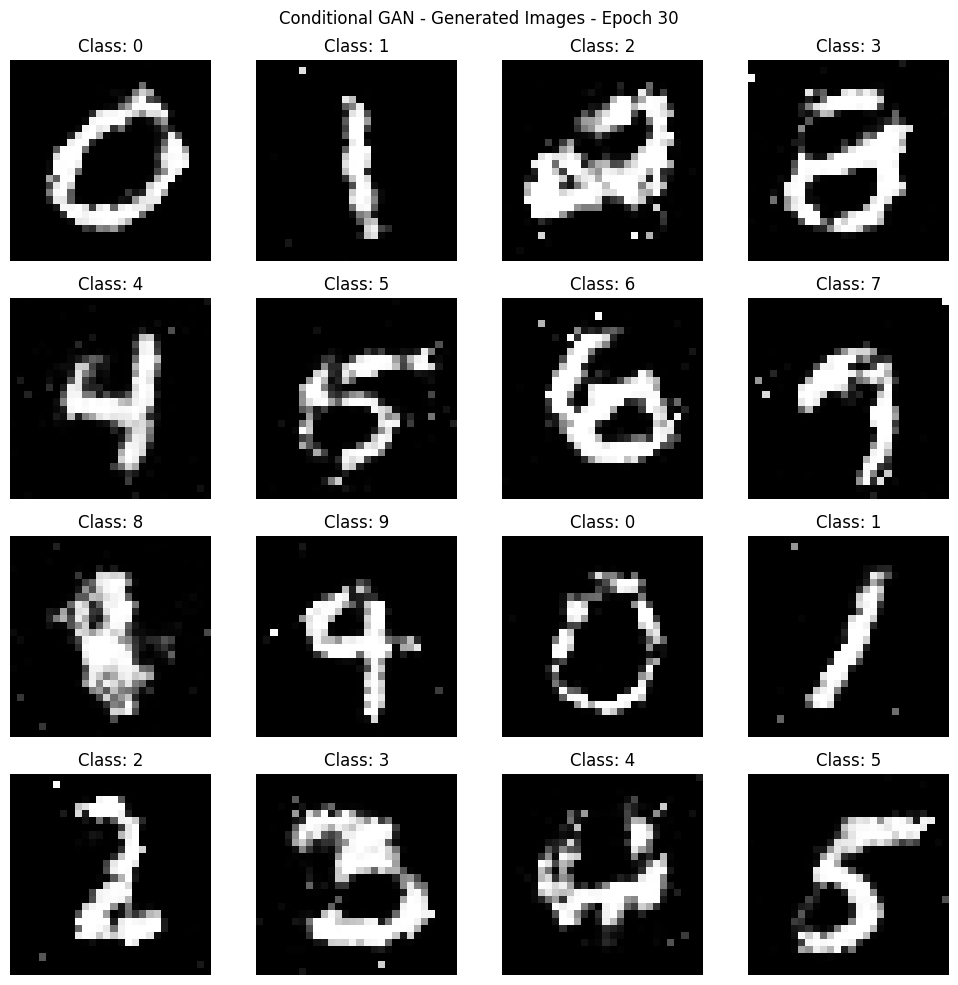

Epoch [31/50] | D Loss: 0.6550 | G Loss: 0.8468
Epoch [32/50] | D Loss: 0.6602 | G Loss: 0.8289
Epoch [33/50] | D Loss: 0.6587 | G Loss: 0.8307
Epoch [34/50] | D Loss: 0.6575 | G Loss: 0.8360
Epoch [35/50] | D Loss: 0.6623 | G Loss: 0.8220
Epoch [36/50] | D Loss: 0.6642 | G Loss: 0.8174
Epoch [37/50] | D Loss: 0.6639 | G Loss: 0.8148
Epoch [38/50] | D Loss: 0.6634 | G Loss: 0.8176
Epoch [39/50] | D Loss: 0.6634 | G Loss: 0.8160
Epoch [40/50] | D Loss: 0.6619 | G Loss: 0.8167


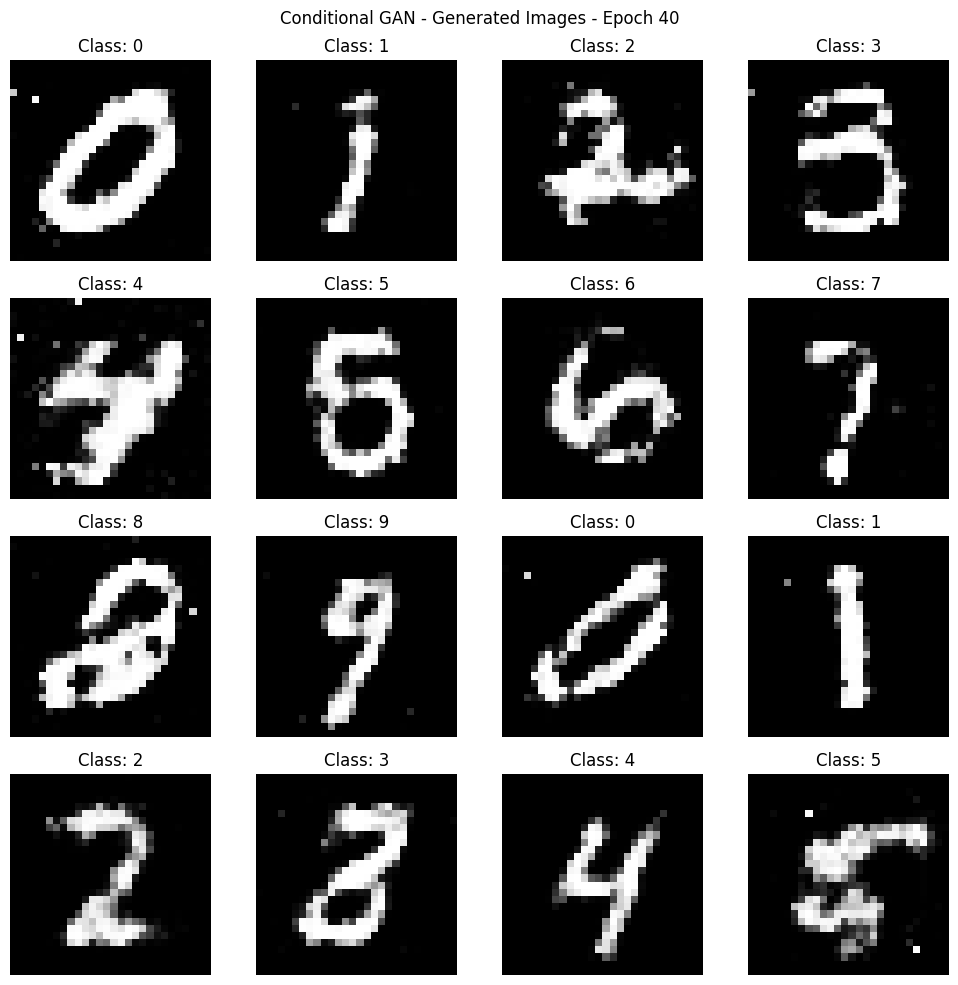

Epoch [41/50] | D Loss: 0.6651 | G Loss: 0.8125
Epoch [42/50] | D Loss: 0.6642 | G Loss: 0.8136
Epoch [43/50] | D Loss: 0.6661 | G Loss: 0.8051
Epoch [44/50] | D Loss: 0.6670 | G Loss: 0.8050
Epoch [45/50] | D Loss: 0.6658 | G Loss: 0.8038
Epoch [46/50] | D Loss: 0.6693 | G Loss: 0.7957
Epoch [47/50] | D Loss: 0.6686 | G Loss: 0.7990
Epoch [48/50] | D Loss: 0.6698 | G Loss: 0.7940
Epoch [49/50] | D Loss: 0.6692 | G Loss: 0.7910
Epoch [50/50] | D Loss: 0.6692 | G Loss: 0.7925


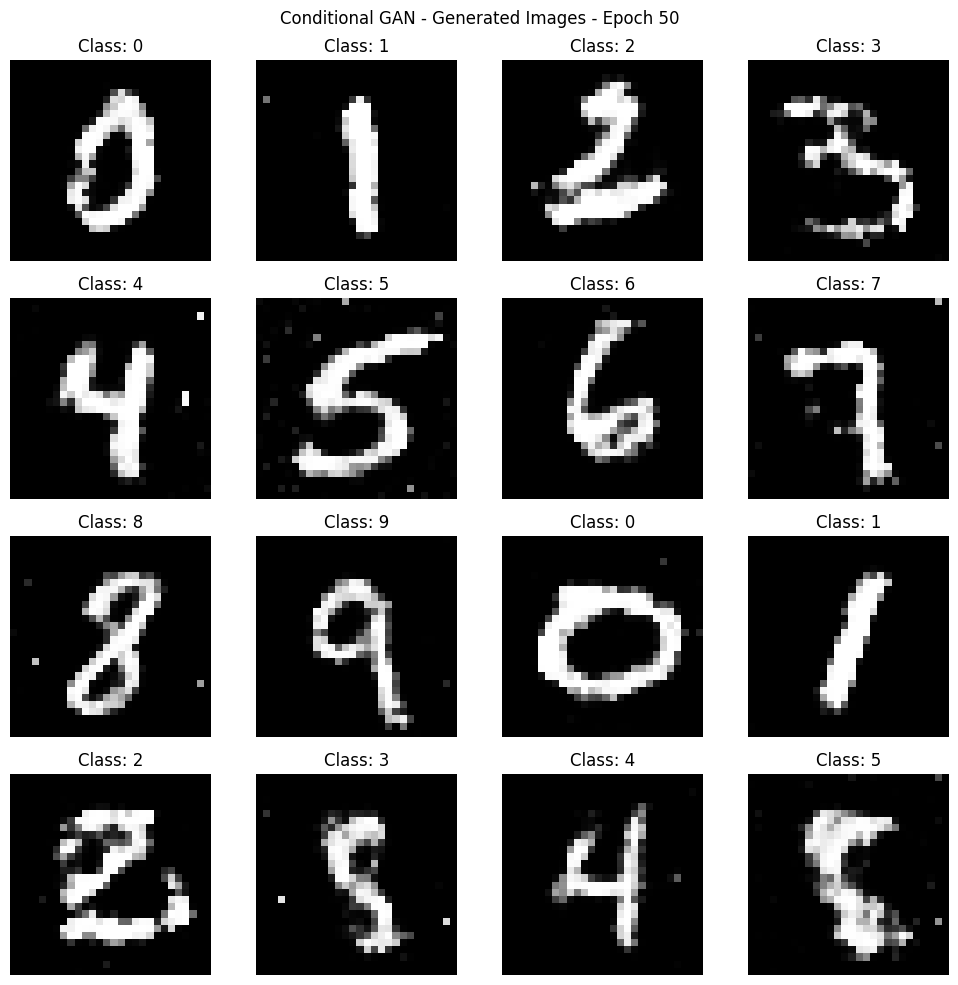


Conditional GAN training completed!
Conditional GAN Generator saved to 'models/cgan_generator.pth'


In [18]:

if cgan_trained:
    print("Skipping Conditional GAN training — loaded from saved model.")
    vis_labels = torch.arange(0, 10).repeat(2).to(device)
    generate_and_visualize(cgan_generator, "Loaded", num_images=16,
                           labels=vis_labels[:16], title_prefix="Conditional GAN (Loaded) - ")
else:
    # Training loop for Conditional GAN
    print("Starting Conditional GAN training...\n")

    cgan_g_losses = []
    cgan_d_losses = []

    for epoch in range(EPOCHS):
        epoch_g_loss = 0
        epoch_d_loss = 0
        
        for batch_idx, (real_imgs, labels) in enumerate(train_loader):
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)
            labels = labels.to(device)
            
            # Labels for real and fake images
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            
            # =================== Train Discriminator ===================
            optimizer_cD.zero_grad()
            
            # Loss on real images with their corresponding labels
            real_validity = cgan_discriminator(real_imgs, labels)
            d_loss_real = criterion(real_validity, real_labels)
            
            # Generate fake images with random labels
            z = torch.randn(batch_size, LATENT_DIM).to(device)
            gen_labels = torch.randint(0, NUM_CLASSES, (batch_size,)).to(device)
            fake_imgs = cgan_generator(z, gen_labels)
            
            # Loss on fake images
            fake_validity = cgan_discriminator(fake_imgs.detach(), gen_labels)
            d_loss_fake = criterion(fake_validity, fake_labels)
            
            # Total discriminator loss
            d_loss = (d_loss_real + d_loss_fake) / 2
            d_loss.backward()
            optimizer_cD.step()
            
            # =================== Train Generator ===================
            optimizer_cG.zero_grad()
            
            # Generate fake images with random labels
            z = torch.randn(batch_size, LATENT_DIM).to(device)
            gen_labels = torch.randint(0, NUM_CLASSES, (batch_size,)).to(device)
            gen_imgs = cgan_generator(z, gen_labels)
            
            # Generator tries to fool discriminator
            validity = cgan_discriminator(gen_imgs, gen_labels)
            g_loss = criterion(validity, real_labels)
            
            g_loss.backward()
            optimizer_cG.step()
            
            # Accumulate losses
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
        
        # Average losses for the epoch
        avg_g_loss = epoch_g_loss / len(train_loader)
        avg_d_loss = epoch_d_loss / len(train_loader)
        cgan_g_losses.append(avg_g_loss)
        cgan_d_losses.append(avg_d_loss)
        
        # Print progress
        print(f"Epoch [{epoch+1}/{EPOCHS}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")
        
        # Visualize generated images every 10 epochs
        if (epoch + 1) % VISUALIZE_EVERY == 0 or epoch == 0:
            # Generate one image for each digit class
            vis_labels = torch.arange(0, 10).repeat(2).to(device)  # 2 of each digit (0-9)
            generate_and_visualize(cgan_generator, epoch+1, num_images=20, 
                                 labels=vis_labels[:16], title_prefix="Conditional GAN - ")

    print("\nConditional GAN training completed!")

    # Save the model after training
    os.makedirs('models', exist_ok=True)
    torch.save({
        'epoch': EPOCHS,
        'model_state_dict': cgan_generator.state_dict(),
        'optimizer_state_dict': optimizer_cG.state_dict(),
        'loss': cgan_g_losses[-1],
    }, CGAN_PATH)
    print(f"Conditional GAN Generator saved to '{CGAN_PATH}'")


## 13. Plot Training Losses for Conditional GAN

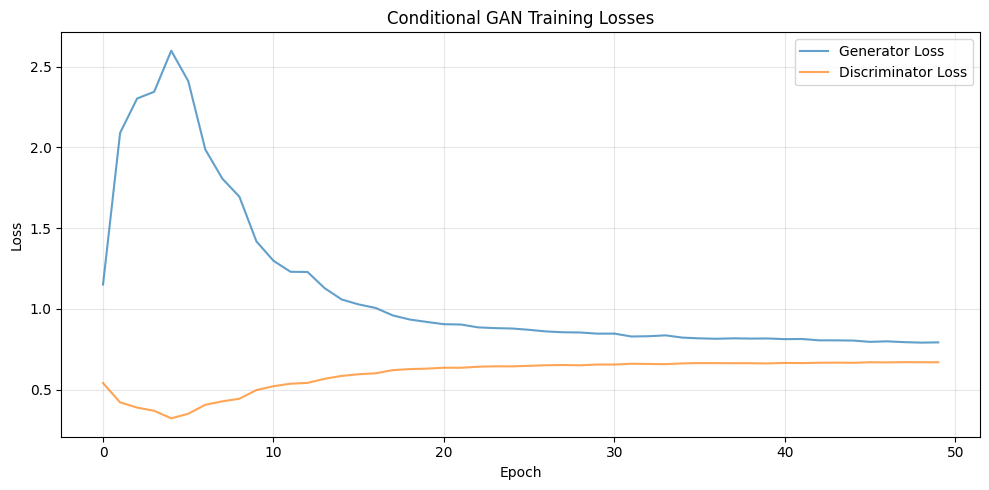

In [19]:
plot_losses(cgan_g_losses, cgan_d_losses, title="Conditional GAN Training Losses")

## 14. Compare Vanilla GAN vs Conditional GAN Losses

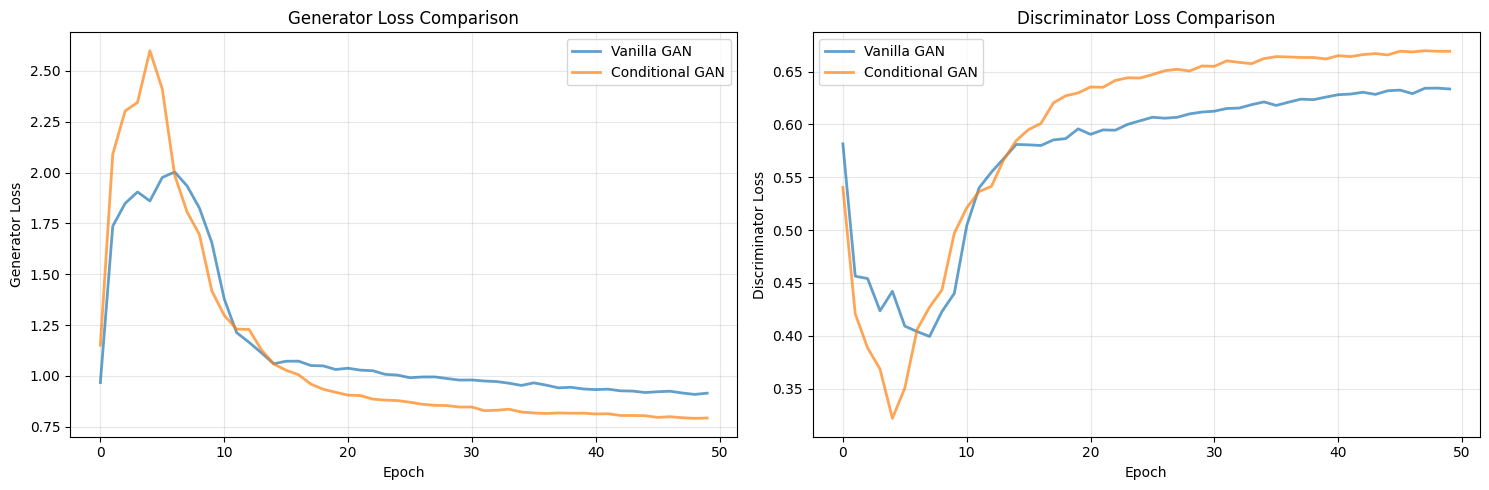

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Generator losses comparison
axes[0].plot(g_losses, label='Vanilla GAN', alpha=0.7, linewidth=2)
axes[0].plot(cgan_g_losses, label='Conditional GAN', alpha=0.7, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Generator Loss')
axes[0].set_title('Generator Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Discriminator losses comparison
axes[1].plot(d_losses, label='Vanilla GAN', alpha=0.7, linewidth=2)
axes[1].plot(cgan_d_losses, label='Conditional GAN', alpha=0.7, linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Discriminator Loss')
axes[1].set_title('Discriminator Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Save Conditional GAN Model

In [21]:
# Save the trained conditional generator
torch.save({
    'epoch': EPOCHS,
    'model_state_dict': cgan_generator.state_dict(),
    'optimizer_state_dict': optimizer_cG.state_dict(),
    'loss': cgan_g_losses[-1],
}, 'models/cgan_generator.pth')

print("Conditional GAN Generator saved to 'models/cgan_generator.pth'")

Conditional GAN Generator saved to 'models/cgan_generator.pth'


## 16. Generate Specific Digits Using Conditional GAN

One of the key advantages of cGAN is the ability to generate specific digit classes on demand.

Generating specific digit class using Conditional GAN...


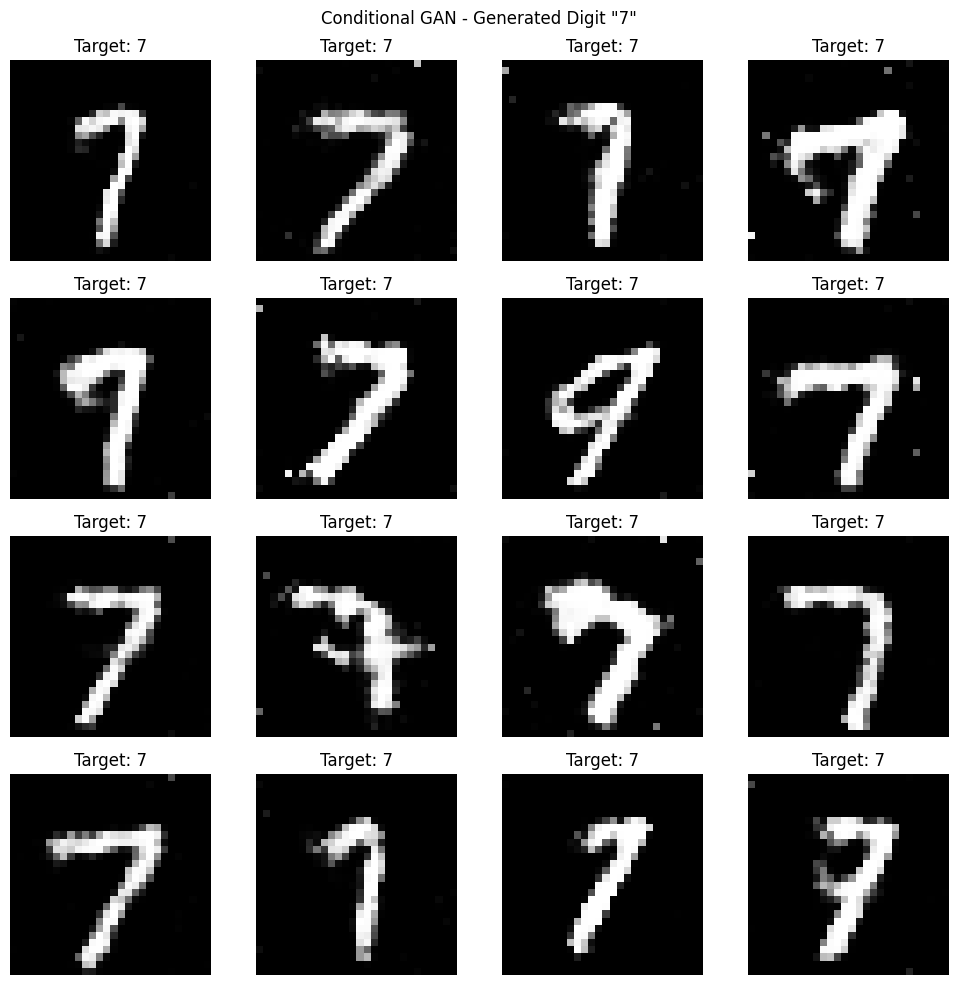

Generator(
  (model): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

In [22]:
# Generate specific digits (e.g., multiple samples of digit '7')
print("Generating specific digit class using Conditional GAN...")

target_digit = 7
num_samples = 16

# Create labels for target digit
target_labels = torch.full((num_samples,), target_digit).to(device)

# Generate images
cgan_generator.eval()
with torch.no_grad():
    z = torch.randn(num_samples, LATENT_DIM).to(device)
    generated_imgs = cgan_generator(z, target_labels)

# Visualize
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    img = generated_imgs[i].cpu().numpy().squeeze()
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f'Target: {target_digit}')

plt.suptitle(f'Conditional GAN - Generated Digit "{target_digit}"')
plt.tight_layout()
plt.show()

cgan_generator.train()

## 17. Generate All Digit Classes (0-9)

Generating all digit classes...


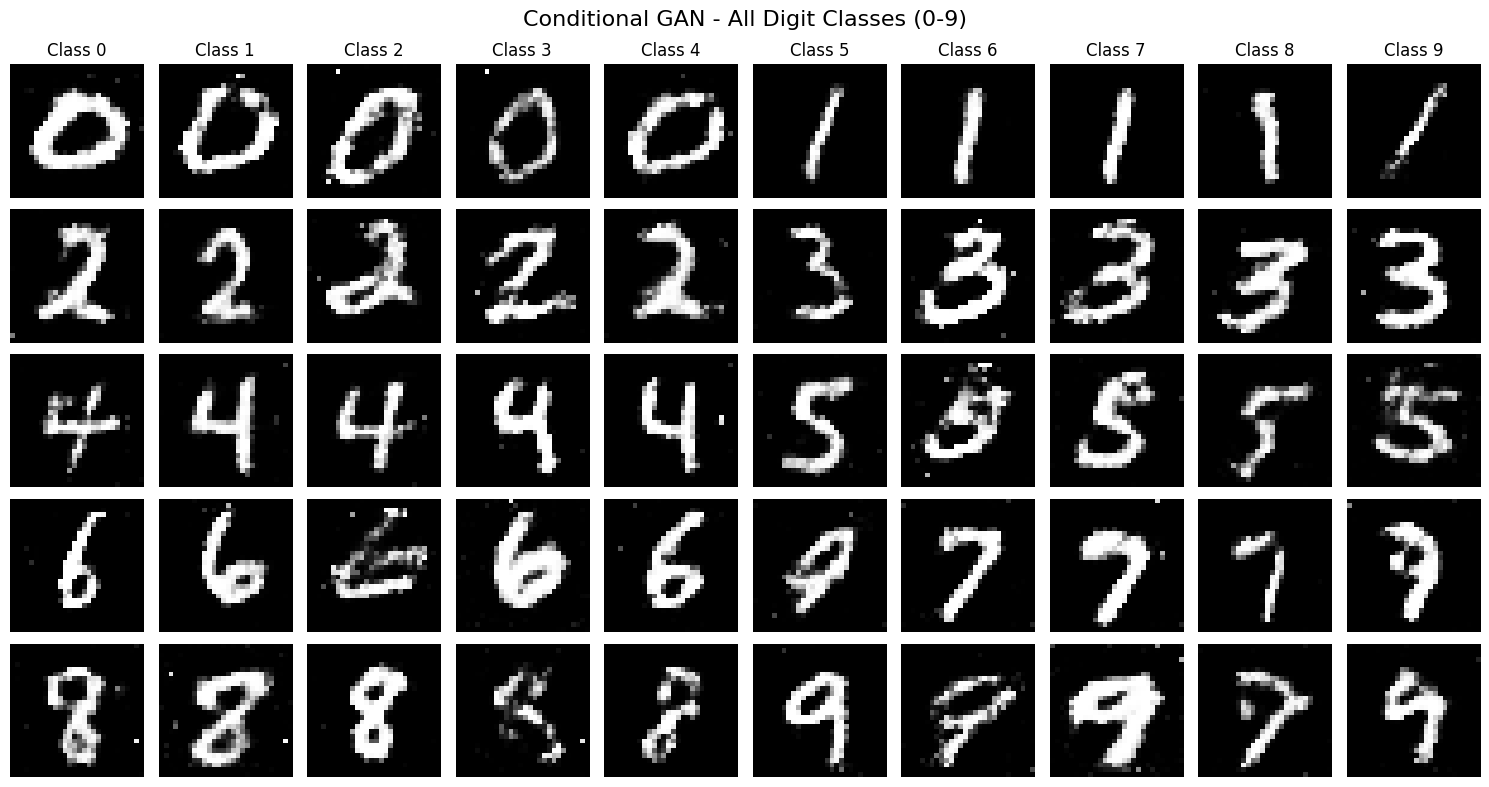

Generator(
  (model): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

In [23]:
# Generate samples for all digit classes
print("Generating all digit classes...")

num_samples_per_class = 5
all_labels = torch.cat([torch.full((num_samples_per_class,), i) for i in range(10)]).to(device)

cgan_generator.eval()
with torch.no_grad():
    z = torch.randn(len(all_labels), LATENT_DIM).to(device)
    generated_imgs = cgan_generator(z, all_labels)

# Visualize in a grid (10 columns for 10 classes, 5 rows for 5 samples each)
fig, axes = plt.subplots(num_samples_per_class, 10, figsize=(15, 8))
for i in range(num_samples_per_class):
    for j in range(10):
        idx = i * 10 + j
        img = generated_imgs[idx].cpu().numpy().squeeze()
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f'Class {j}', fontsize=12)

plt.suptitle('Conditional GAN - All Digit Classes (0-9)', fontsize=16)
plt.tight_layout()
plt.show()

cgan_generator.train()

## 18. Quality Comparison: Vanilla GAN vs Conditional GAN

Visual comparison of generated images from both models.

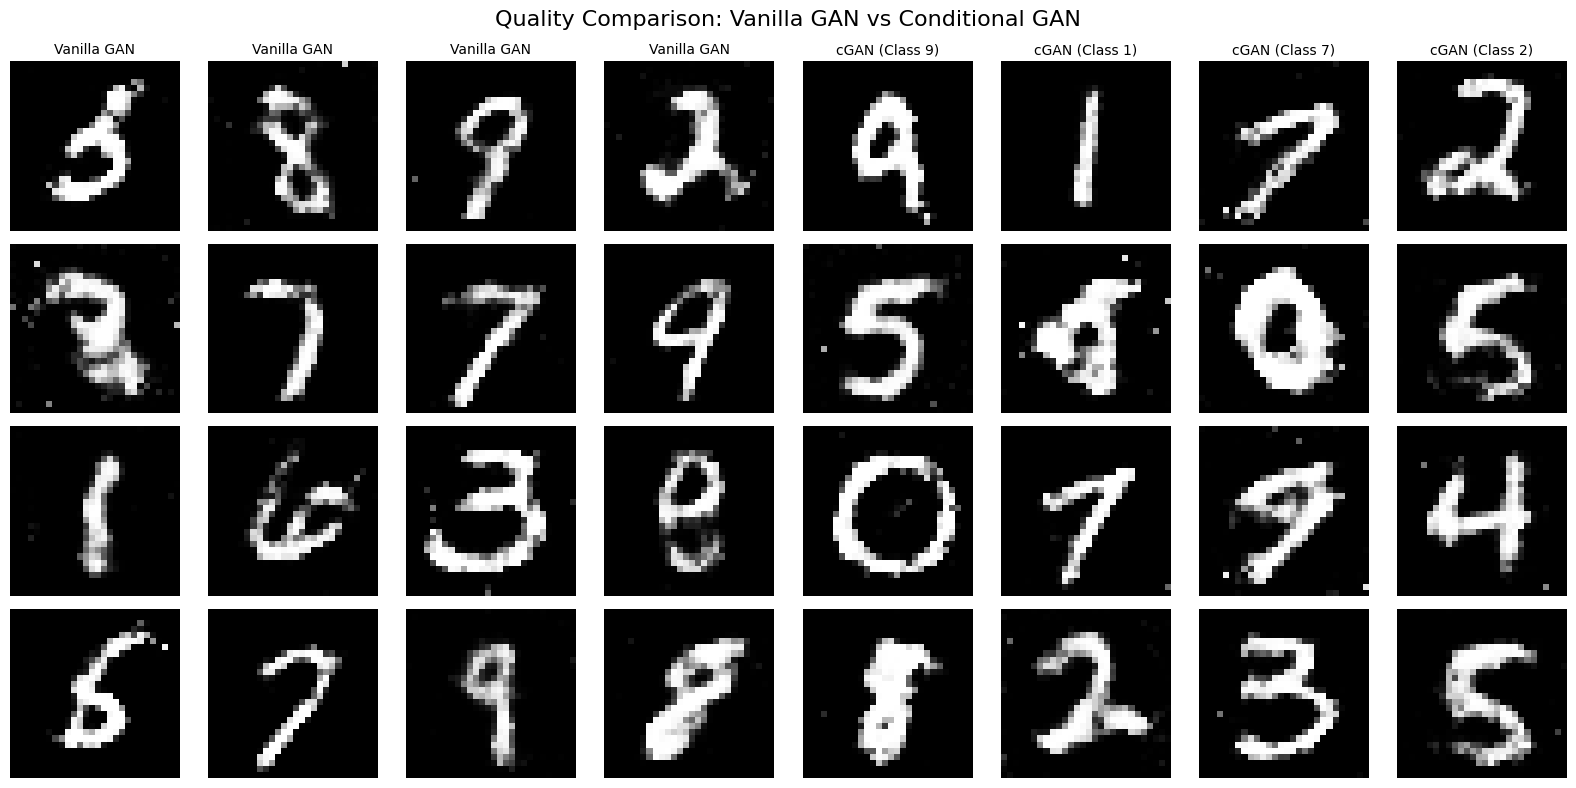

Generator(
  (model): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

In [24]:
# Generate samples from both models for comparison
num_compare = 16

# Vanilla GAN samples
generator.eval()
with torch.no_grad():
    z = torch.randn(num_compare, LATENT_DIM).to(device)
    vanilla_imgs = generator(z)

# Conditional GAN samples (random classes)
cgan_generator.eval()
with torch.no_grad():
    z = torch.randn(num_compare, LATENT_DIM).to(device)
    labels = torch.randint(0, 10, (num_compare,)).to(device)
    cgan_imgs = cgan_generator(z, labels)

# Side-by-side comparison
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

# Plot vanilla GAN on left side
for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        img = vanilla_imgs[idx].cpu().numpy().squeeze()
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title('Vanilla GAN', fontsize=10)

# Plot conditional GAN on right side
for i in range(4):
    for j in range(4, 8):
        idx = i * 4 + (j - 4)
        img = cgan_imgs[idx].cpu().numpy().squeeze()
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f'cGAN (Class {labels[idx].item()})', fontsize=10)

plt.suptitle('Quality Comparison: Vanilla GAN vs Conditional GAN', fontsize=16)
plt.tight_layout()
plt.show()

generator.train()
cgan_generator.train()

## 19. Summary and Observations

### Key Findings:

1. **Vanilla GAN:**
   - Generates diverse handwritten digits
   - No control over which digit is generated
   - Training can be unstable due to mode collapse

2. **Conditional GAN:**
   - Provides control over generated digit class
   - Generally produces more stable training
   - Can generate specific digits on demand
   - Useful for targeted data augmentation

3. **Architecture Flexibility:**
   - The modular design allows easy switching between vanilla and conditional modes
   - Adding conditioning required minimal code changes (one-hot encoding and concatenation)

4. **Training Observations:**
   - Both models converge successfully
   - Loss curves show typical GAN training dynamics
   - Image quality improves progressively over epochs

## 20. Load Saved Models for Inference (Optional)

In [25]:
# Example: Load saved vanilla GAN generator
def load_generator(model_path, conditional=False):
    """
    Load a saved generator model.
    
    Args:
        model_path: Path to saved model
        conditional: Whether model is conditional
    
    Returns:
        Loaded generator model
    """
    # Create model
    loaded_gen = Generator(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, 
                          conditional=conditional).to(device)
    
    # Load checkpoint
    checkpoint = torch.load(model_path)
    loaded_gen.load_state_dict(checkpoint['model_state_dict'])
    loaded_gen.eval()
    
    print(f"Model loaded from {model_path}")
    print(f"Trained for {checkpoint['epoch']} epochs")
    print(f"Final loss: {checkpoint['loss']:.4f}")
    
    return loaded_gen

# Example usage:
# loaded_vanilla_gen = load_generator('models/vanilla_gan_generator.pth', conditional=False)
# loaded_cgan_gen = load_generator('models/cgan_generator.pth', conditional=True)

## Conclusion

This notebook successfully implements:
1. ✅ Vanilla GAN trained on MNIST
2. ✅ Conditional GAN (cGAN) extension
3. ✅ Flexible architecture supporting both modes
4. ✅ Proper training loops with adversarial learning
5. ✅ Visualization of generated samples
6. ✅ Model saving and loading capabilities
7. ✅ Comparative analysis of both approaches

The implementation demonstrates understanding of:
- GAN architecture and training dynamics
- Conditional generation using label information
- PyTorch deep learning framework
- Best practices in model design and training